In [1]:
import polars as pl
import glob
import matplotlib.pyplot as plt

In [2]:
# base checkout of workflow directory is here:
BASE='/home/ctbrown/scratch3/2025-workflow-core99/'

# parquet files from 'sourmash gather' against 3,216 metagenomes
BASE_OUTPUTS=BASE+'/outputs.core2'

# where to place figures
FIG_OUT=BASE+'/outputs.figures/'

THRESHOLD_BP=20_000
N_METAGENOMES=3216

In [3]:
extract_species_from_name = (pl.col("match_name")
                             .str.split(' ')
                             .list.slice(1, 2)
                             .list.join(' '))

In [4]:
names_core = set([ x.strip() for x in open('../inputs.cds/names.list') ])
names_large = set([ x.strip() for x in open('../inputs.cds/names-plus.list') ])

names_core.add('s__Escherichia coli')
names_large.add('s__Escherichia coli')

In [5]:
filenames = glob.glob(BASE_OUTPUTS + '/*.parquet')

dflist = []

all_df = (pl.scan_parquet(filenames)
          .with_columns(species=extract_species_from_name)
          .filter(pl.col("species").is_in(names_large))
          .select(["species", "match_name", "containment", "query_name", "intersect_hashes", "scaled"])).collect()


In [6]:
assert all_df["query_name"].n_unique() == N_METAGENOMES
print(f"loaded {all_df['query_name'].n_unique()} gathers.")

loaded 3216 gathers.


In [7]:
all_df = all_df.with_columns((pl.col("intersect_hashes") * pl.col("scaled")).alias("intersect_bp"))

In [8]:
#all_df = all_df.filter(pl.col("intersect_bp") >= THRESHOLD_BP)

In [9]:
group_df = (all_df.group_by('species')
            .agg(pl.len())
            .with_columns(frequency=pl.col("len") / N_METAGENOMES))

            
group_df

species,len,frequency
str,u32,f64
"""s__Cryptobacteroides sp0004326…",3204,0.996269
"""s__Bariatricus sp004560705""",3210,0.998134
"""s__Ruminococcus_C sp000433635""",3106,0.965796
"""s__Escherichia coli""",3216,1.0
"""s__Prevotella sp002251295""",3213,0.999067
…,…,…
"""s__Cryptobacteroides sp0340892…",3197,0.994092
"""s__Mogibacterium_A kristiansen…",3207,0.997201
"""s__CAG-465 sp000433755""",2671,0.830535


In [10]:
kmer_df = pl.read_parquet('../inputs.abundhist/kmer-coverage.parquet')
kmer_df

query_name,query_md5,match_name,containment,intersect_hashes,ksize,scaled,moltype,match_md5,jaccard,max_containment,average_abund,median_abund,std_abund,query_containment_ani,match_containment_ani,average_containment_ani,max_containment_ani,n_weighted_found,total_weighted_hashes,species,metag,sketch_size,intersect_bp,weighted_bp,breadth,depth,fit_breadth
str,str,str,f64,i64,i64,i64,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,str,str,f64,i64,i64,f64,f64,f64
"""s__Cryptobacteroides sp0004326…","""33ab318886b78679c8de5e106ac6b9…","""SRR11125436""",0.045958,191,21,1000,"""DNA""","""3d446d163d0e662dcfc977bd359509…",0.000536,0.045958,1.356021,1.0,0.744229,0.86358,0.698971,0.781276,0.86358,259,950458,"""s__Cryptobacteroides sp0004326…","""SRR11125436""",4.156e6,191000,259000,0.204354,0.277108,0.19245
"""s__Bariatricus sp004560705""","""a053514b987f8c11e2ed518938e366…","""SRR11125436""",0.127554,387,21,1000,"""DNA""","""3d446d163d0e662dcfc977bd359509…",0.001089,0.127554,1.757106,1.0,1.189063,0.906597,0.722874,0.814735,0.906597,680,950458,"""s__Bariatricus sp004560705""","""SRR11125436""",3.034e6,387000,680000,0.371028,0.651935,0.343385
"""s__Floccifex porci""","""d517f763cae95c3706b3311e9ef0ca…","""SRR11125436""",0.071151,165,21,1000,"""DNA""","""3d446d163d0e662dcfc977bd359509…",0.000465,0.071151,1.569697,1.0,1.192015,0.881743,0.694117,0.78793,0.881743,259,950458,"""s__Floccifex porci""","""SRR11125436""",2.319e6,165000,259000,0.162333,0.254813,0.159372
"""s__Cryptobacteroides sp0340892…","""376b4bdd83505f2f45acbe381d3914…","""SRR11125436""",0.097169,254,21,1000,"""DNA""","""3d446d163d0e662dcfc977bd359509…",0.000715,0.097169,1.767717,1.0,1.165946,0.894926,0.708524,0.801725,0.894926,449,950458,"""s__Cryptobacteroides sp0340892…","""SRR11125436""",2.614e6,254000,449000,0.309885,0.547788,0.300585
"""s__Prevotella sp000434975""","""4736bc318783e81245554ed9fa261a…","""SRR11125436""",0.001619,11,21,1000,"""DNA""","""3d446d163d0e662dcfc977bd359509…",0.000031,0.001619,1.090909,1.0,0.28748,0.73639,0.610139,0.673264,0.73639,12,950458,"""s__Prevotella sp000434975""","""SRR11125436""",6.794e6,11000,12000,0.008607,0.009389,0.003399
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""s__Colivicinus sp002299675""","""751a24e45a6cdebaf4daf12fd0f355…","""ERR8314784""",0.382275,1294,21,1000,"""DNA""","""45f6f8c60b8f927c4b40ceae028c5c…",0.000483,0.382275,2.958269,2.0,2.231873,0.955241,0.695173,0.825207,0.955241,3828,11178711,"""s__Colivicinus sp002299675""","""ERR8314784""",3.385e6,1294000,3828000,0.784773,2.321568,0.812484
"""s__CAG-269 sp014846485""","""078c4569f257f75356832c47c16808…","""ERR8314784""",0.002294,1,21,1000,"""DNA""","""45f6f8c60b8f927c4b40ceae028c5c…",3.7320e-7,0.002294,1.0,1.0,0.0,0.748704,0.494203,0.621453,0.748704,1,11178711,"""s__CAG-269 sp014846485""","""ERR8314784""",436000.0,1000,1000,0.00441,0.00441,0.003491
"""s__UMGS1225 sp034086705""","""32711230ebb0936ab57ed263368289…","""ERR8314784""",0.051258,55,21,1000,"""DNA""","""45f6f8c60b8f927c4b40ceae028c5c…",0.000021,0.051258,1.272727,1.0,0.645391,0.868081,0.598108,0.733094,0.868081,70,11178711,"""s__UMGS1225 sp034086705""","""ERR8314784""",1.073e6,55000,70000,0.059676,0.075952,0.061348


In [11]:
kmer_med_df = kmer_df.group_by('species').agg(
    pl.col('depth').median()
)
kmer_med_df

species,depth
str,f64
"""s__Prevotella sp000434975""",0.400225
"""s__Sodaliphilus sp004557565""",3.1657
"""s__Cryptobacteroides sp0340892…",0.873534
"""s__Floccifex porci""",0.77231
"""s__Fimisoma sp002320005""",0.736569
…,…
"""s__CAG-873 sp016302215""",0.014134
"""s__CAG-465 sp000433755""",0.054132
"""s__Ventricola sp017937505""",0.056553


In [12]:
join_df = group_df.join(kmer_med_df, on='species', how='inner')
join_df

species,len,frequency,depth
str,u32,f64,f64
"""s__Cryptobacteroides sp0004326…",3204,0.996269,0.865027
"""s__Bariatricus sp004560705""",3210,0.998134,0.987969
"""s__Ruminococcus_C sp000433635""",3106,0.965796,0.074484
"""s__Prevotella sp002251295""",3213,0.999067,1.16559
"""s__Cryptobacteroides sp9005469…",3207,0.997201,1.195034
…,…,…,…
"""s__Cryptobacteroides sp0340892…",3197,0.994092,0.873534
"""s__Mogibacterium_A kristiansen…",3207,0.997201,2.812068
"""s__CAG-465 sp000433755""",2671,0.830535,0.054132


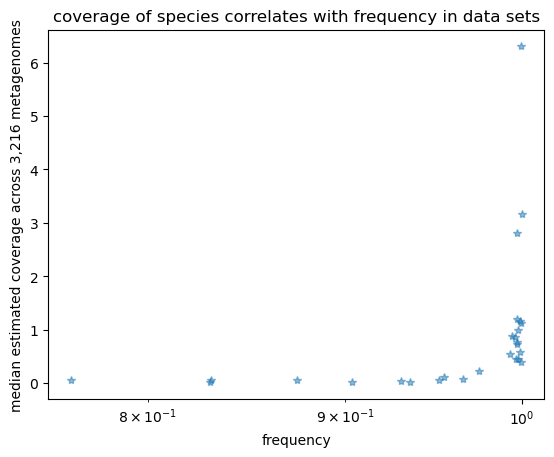

In [13]:
plt.plot(join_df['frequency'], join_df['depth'], '*', alpha=0.5)
plt.xscale('log')
plt.xlabel('frequency')
plt.ylabel('median estimated coverage across 3,216 metagenomes')
plt.title('coverage of species correlates with frequency in data sets')
plt.savefig('../outputs.figures/figure3-cov-freq.png')